# 05: Evaluation and SHAP Explainability
**Project:** Robust Financial Fraud Detection using GNNs and Multimodal Fusion
**Author:** Israt Islam | 23082056 | University of Hertfordshire
**Purpose:** Final evaluation of all models, SHAP explainability analysis, and generation of all thesis-ready figures.

---

## 1. Setup and Install SHAP
SHAP (SHapley Additive exPlanations) is the industry standard library for ML explainability. It explains individual predictions by attributing contribution to each feature.

In [1]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/FraudProject'

# ── Install SHAP ──────────────────────────────────────────────────────────────
!pip install shap -q

# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import shap   # for explainability analysis

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, average_precision_score
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

def savefig(name):
    """
    Save current matplotlib figure to /figures/ at 300dpi.

    Args:
        name (str): Filename without extension
    """
    plt.savefig(f'{BASE}/figures/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved -> figures/{name}.png')

print('Setup done.')

Mounted at /content/drive
Device: cuda
Setup done.


## 2. Load All Data and Models
Load preprocessed test data and all trained models from previous notebooks.

In [2]:
# ── Load test data ────────────────────────────────────────────────────────────
print('Loading data...')
X_train = pd.read_parquet(f'{BASE}/processed/X_train.parquet')
X_test  = pd.read_parquet(f'{BASE}/processed/X_test.parquet')
y_train = np.load(f'{BASE}/processed/y_train.npy')
y_test  = np.load(f'{BASE}/processed/y_test.npy')

# Clean infinite values
for df in [X_train, X_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

# ── Load all trained models ───────────────────────────────────────────────────
print('Loading models...')
scaler = joblib.load(f'{BASE}/models/scaler.pkl')     # for Logistic Regression
lr     = joblib.load(f'{BASE}/models/lr_model.pkl')   # Logistic Regression
rf     = joblib.load(f'{BASE}/models/rf_model.pkl')   # Random Forest
xgb    = joblib.load(f'{BASE}/models/xgb_model.pkl')  # XGBoost (main SHAP target)
lgbm   = joblib.load(f'{BASE}/models/lgbm_model.pkl') # LightGBM

# ── Load results tables ───────────────────────────────────────────────────────
master_df   = pd.read_csv(f'{BASE}/processed/results_master.csv',   index_col='Model')
ablation_df = pd.read_csv(f'{BASE}/processed/ablation_results.csv', index_col=0)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print('All models and data loaded.')

Loading data...
Loading models...
X_train: (472432, 365)
X_test:  (118108, 365)
All models and data loaded.


## 3. Master Results Table
The complete comparison of all 6 models. This is the primary results table for the thesis Results chapter.

In [3]:
# ── Display master results table ─────────────────────────────────────────────
cols = ['AUC-ROC','F1','Precision','Recall','FPR']
print('MASTER RESULTS TABLE - ALL 6 MODELS')
print('='*70)
print(master_df[cols].to_string())
print('='*70)
print(f"Best AUC-ROC: {master_df['AUC-ROC'].idxmax()} ({master_df['AUC-ROC'].max():.4f})")
print(f"Best F1:      {master_df['F1'].idxmax()} ({master_df['F1'].max():.4f})")
print(f"Lowest FPR:   {master_df['FPR'].idxmin()} ({master_df['FPR'].min():.4f})")

MASTER RESULTS TABLE - ALL 6 MODELS
                      AUC-ROC      F1  Precision  Recall     FPR
Model                                                           
Logistic Regression    0.8306  0.1703     0.0959  0.7625  0.2563
Random Forest          0.8715  0.3207     0.2156  0.6257  0.0811
XGBoost                0.9127  0.3683     0.2486  0.7096  0.0764
LightGBM               0.9099  0.3506     0.2321  0.7160  0.0844
GraphSAGE              0.8551  0.1961     0.1126  0.7574  0.2127
Fusion (GNN+Tabular)   0.8551  0.2251     0.1338  0.7089  0.1635
Best AUC-ROC: XGBoost (0.9127)
Best F1:      XGBoost (0.3683)
Lowest FPR:   XGBoost (0.0764)


## 4. ROC Curves — All Baseline Models
ROC curves showing the progression from Logistic Regression to XGBoost.

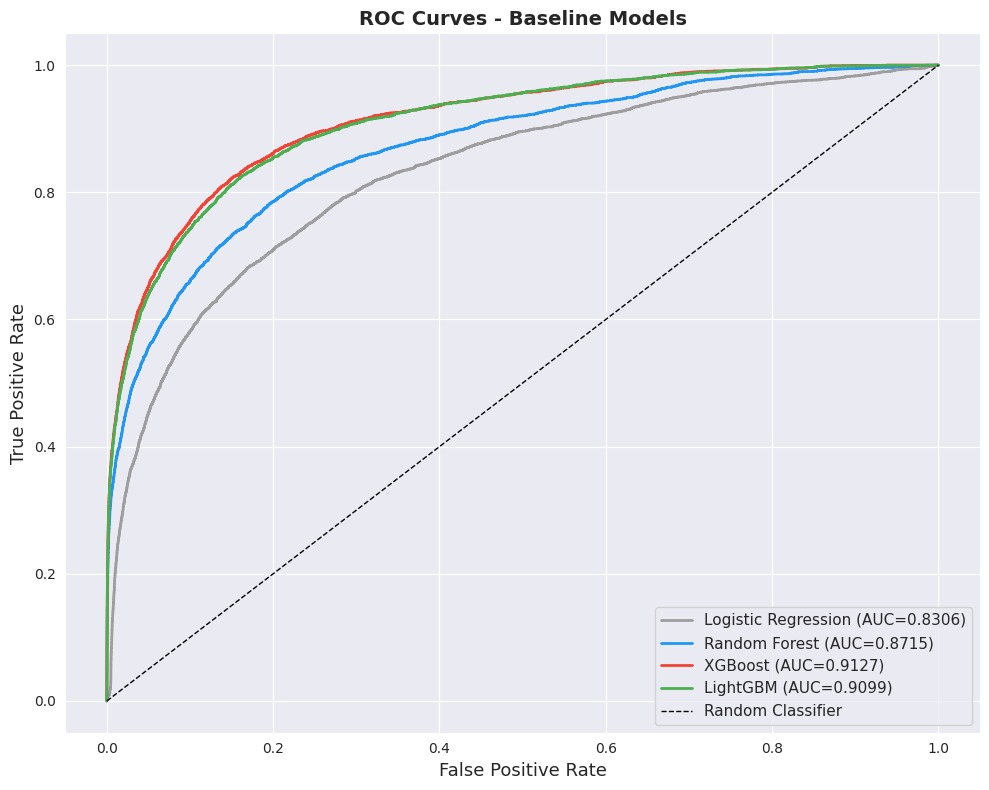

  Saved -> figures/25_roc_baselines_final.png


In [4]:
# ── Scale test set for Logistic Regression ───────────────────────────────────
X_test_sc = scaler.transform(X_test)
palette   = ['#9E9E9E','#2196F3','#F44336','#4CAF50']

# ── Generate predictions for all baseline models ──────────────────────────────
model_probs = [
    ('Logistic Regression', lr.predict_proba(X_test_sc)[:,1]),
    ('Random Forest',       rf.predict_proba(X_test)[:,1]),
    ('XGBoost',             xgb.predict_proba(X_test)[:,1]),
    ('LightGBM',            lgbm.predict_proba(X_test)[:,1]),
]

plt.figure(figsize=(10, 8))
for (name, probs), color in zip(model_probs, palette):
    fpr_c, tpr_c, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr_c, tpr_c, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - Baseline Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
savefig('25_roc_baselines_final')

## 5. Precision-Recall Curves
More informative than ROC curves for imbalanced datasets. Shows the trade-off between catching fraud and avoiding false alarms.

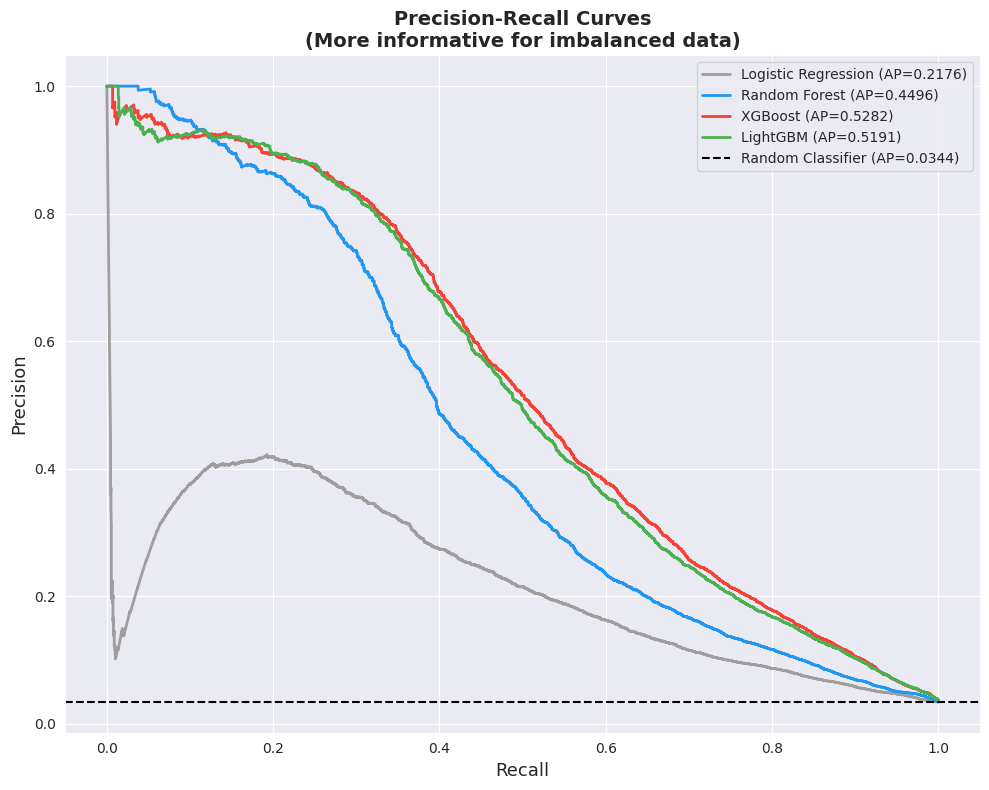

  Saved -> figures/26_precision_recall_final.png


In [5]:
plt.figure(figsize=(10, 8))

for (name, probs), color in zip(model_probs, palette):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)  # area under PR curve
    plt.plot(rec, prec, label=f'{name} (AP={ap:.4f})', color=color, linewidth=2)

# Horizontal line = random classifier performance at fraud rate
plt.axhline(
    y_test.mean(), color='black', linestyle='--',
    label=f'Random Classifier (AP={y_test.mean():.4f})'
)
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curves\n(More informative for imbalanced data)',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
savefig('26_precision_recall_final')

## 6. SHAP Feature Importance (3-5 minutes)
SHAP TreeExplainer computes exact Shapley values for tree-based models. We use 5,000 representative samples — standard practice for SHAP on large datasets (Lundberg et al., 2017).

Computing SHAP values on 5,000 sample...
(Using sample is standard practice for SHAP on large datasets)
SHAP values computed. Shape: (5000, 365)


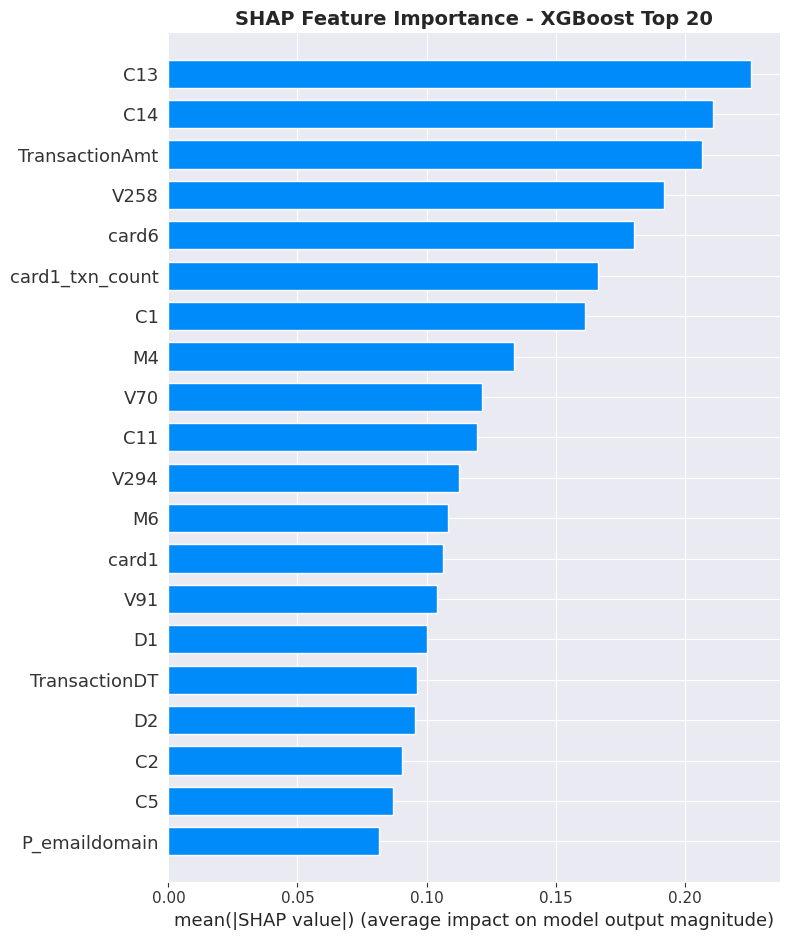

  Saved -> figures/27_shap_summary_bar.png


In [6]:
print('Computing SHAP values on 5,000 sample...')
print('(Using sample is standard practice for SHAP on large datasets)')

# ── Sample 5,000 test transactions ───────────────────────────────────────────
# 5,000 is sufficient for stable SHAP values per Lundberg et al. (2017)
np.random.seed(42)  # reproducibility
sample_idx  = np.random.choice(len(X_test), 5000, replace=False)
X_test_shap = X_test.iloc[sample_idx]   # sampled feature matrix
y_test_shap = y_test[sample_idx]        # corresponding labels

# ── Compute SHAP values using TreeExplainer ───────────────────────────────────
# TreeExplainer is exact and fast for XGBoost/LightGBM
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_shap)  # shape: (5000, n_features)
print(f'SHAP values computed. Shape: {shap_values.shape}')

# ── SHAP Summary Bar Plot ─────────────────────────────────────────────────────
# Shows mean absolute SHAP value per feature (overall importance)
plt.figure()
shap.summary_plot(
    shap_values, X_test_shap,
    plot_type='bar',    # bar chart of mean |SHAP|
    max_display=20,     # show top 20 features
    show=False
)
plt.title('SHAP Feature Importance - XGBoost Top 20', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('27_shap_summary_bar')

## 7. SHAP Beeswarm Plot
Shows not just which features matter but **how** they affect predictions. Red = high feature value, Blue = low. X-axis shows direction of impact (positive = pushes toward fraud).

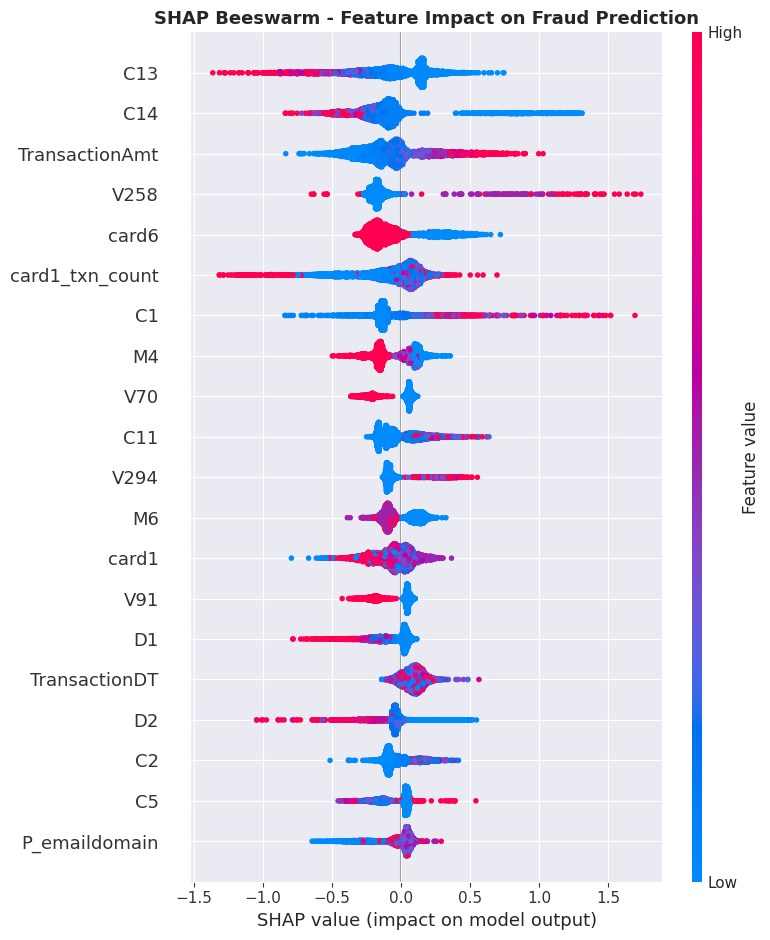

  Saved -> figures/28_shap_beeswarm.png


In [7]:
# ── SHAP Beeswarm Plot ────────────────────────────────────────────────────────
# Each dot is one transaction. Colour = feature value. X-axis = SHAP impact.
plt.figure()
shap.summary_plot(
    shap_values, X_test_shap,
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm - Feature Impact on Fraud Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('28_shap_beeswarm')

## 8. SHAP Waterfall Plots
Explains individual predictions by showing exactly which features pushed a transaction toward fraud or legitimate. We show 2 fraud cases and 1 legitimate case.

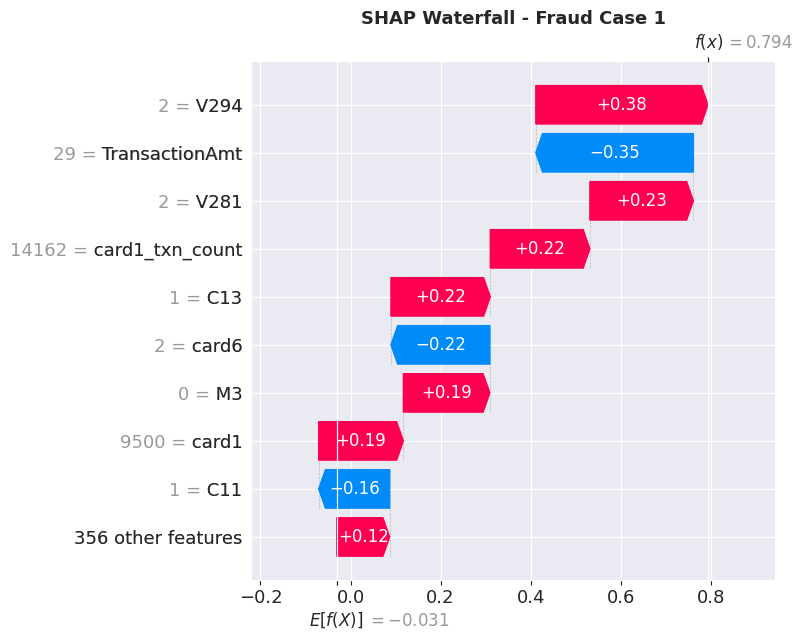

  Saved -> figures/29_shap_waterfall_fraud1.png
  Fraud Case 1: done.


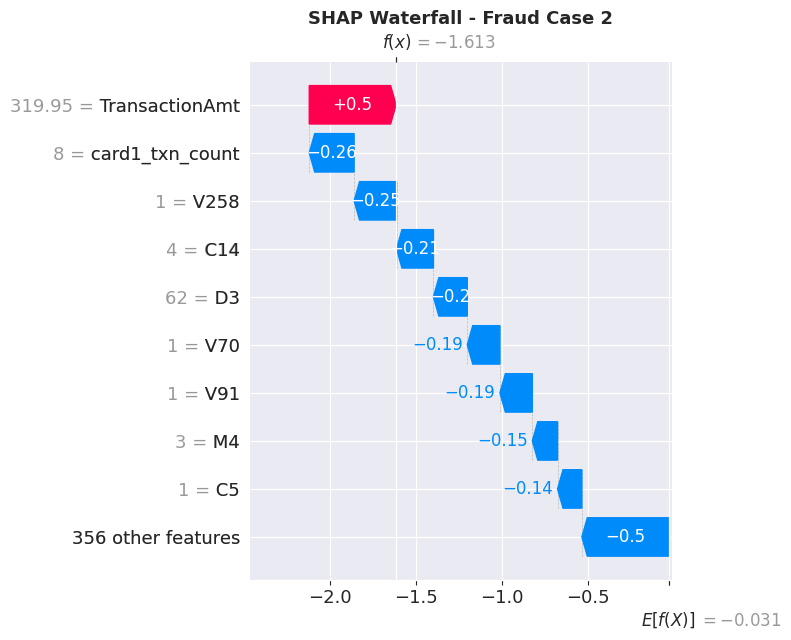

  Saved -> figures/30_shap_waterfall_fraud2.png
  Fraud Case 2: done.


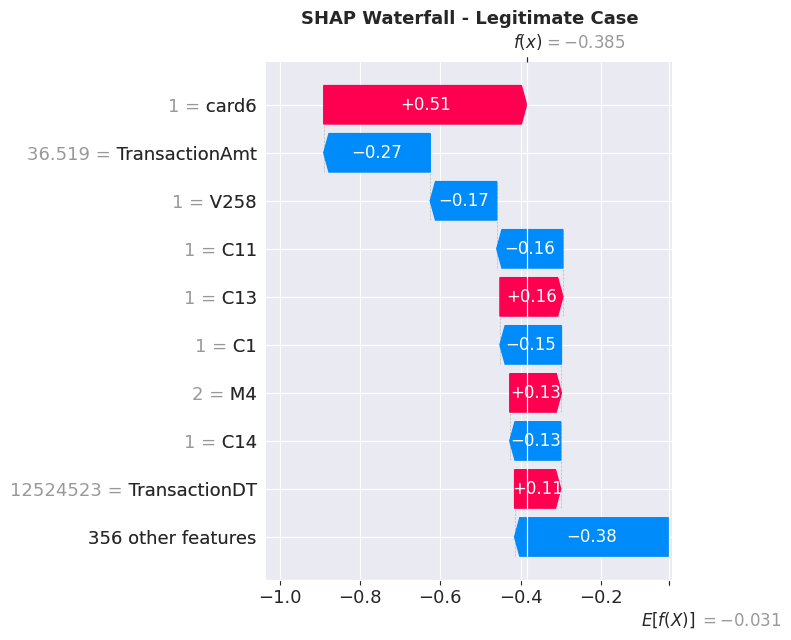

  Saved -> figures/31_shap_waterfall_legit.png
  Legitimate Case: done.


In [8]:
# ── Find fraud and legitimate indices in the sample ───────────────────────────
fraud_indices = np.where(y_test_shap == 1)[0]  # indices of actual fraud cases
legit_indices = np.where(y_test_shap == 0)[0]  # indices of legitimate cases

# ── Generate waterfall plots for 3 individual predictions ────────────────────
for label, idx, fname in [
    ('Fraud Case 1', fraud_indices[0], '29_shap_waterfall_fraud1'),
    ('Fraud Case 2', fraud_indices[1], '30_shap_waterfall_fraud2'),
    ('Legitimate Case', legit_indices[0], '31_shap_waterfall_legit'),
]:
    plt.figure()
    # Waterfall plot shows base value + feature contributions -> final prediction
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],              # SHAP values for this sample
            base_values=explainer.expected_value,  # model's average prediction
            data=X_test_shap.iloc[idx],           # feature values for this sample
            feature_names=list(X_test_shap.columns)
        ),
        show=False
    )
    plt.title(f'SHAP Waterfall - {label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig(fname)
    print(f'  {label}: done.')

## 9. SHAP Dependence Plots
Shows how a feature's value affects its SHAP impact across all transactions. Reveals non-linear relationships and feature interactions.

Top 3 features by SHAP importance: ['C13', 'C14', 'TransactionAmt']


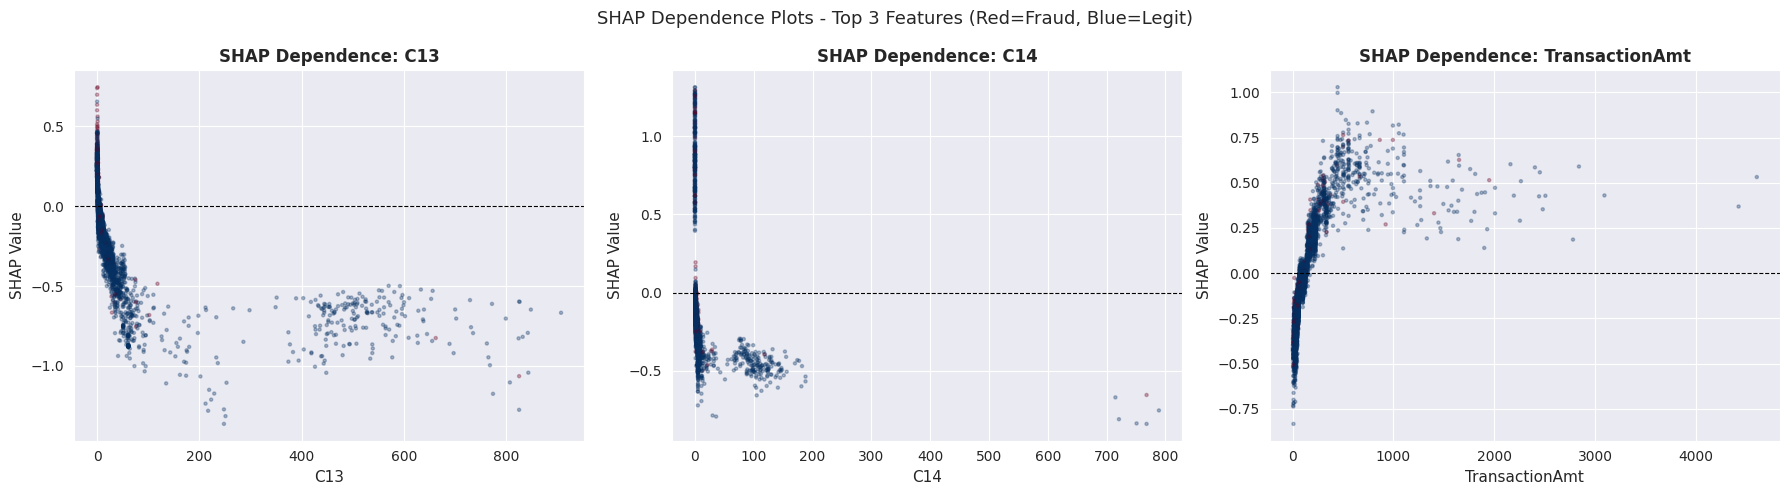

  Saved -> figures/32_shap_dependence.png


In [9]:
# ── Compute feature importance from SHAP values ───────────────────────────────
# Mean absolute SHAP value = global feature importance
feature_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),  # average across all samples
    index=X_test_shap.columns
).sort_values(ascending=False)

# ── Get top 3 most important features ────────────────────────────────────────
top3 = feature_importance.head(3).index.tolist()
print(f'Top 3 features by SHAP importance: {top3}')

# ── Plot dependence plots for top 3 features ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3):
    feat_idx = list(X_test_shap.columns).index(feat)  # get column index

    # Scatter: x=feature value, y=SHAP value, colour=fraud label
    ax.scatter(
        X_test_shap[feat].values,
        shap_values[:, feat_idx],
        c=y_test_shap,      # colour by actual fraud label
        cmap='RdBu_r',      # red=fraud, blue=legit
        alpha=0.3, s=5
    )
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('SHAP Value', fontsize=11)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)  # zero line

plt.suptitle('SHAP Dependence Plots - Top 3 Features (Red=Fraud, Blue=Legit)',
             fontsize=13)
plt.tight_layout()
savefig('32_shap_dependence')

## 10. SHAP: Engineered vs Original Features
Compares the importance of our 7 engineered features against the original dataset features. Validates whether our feature engineering added genuine predictive value.

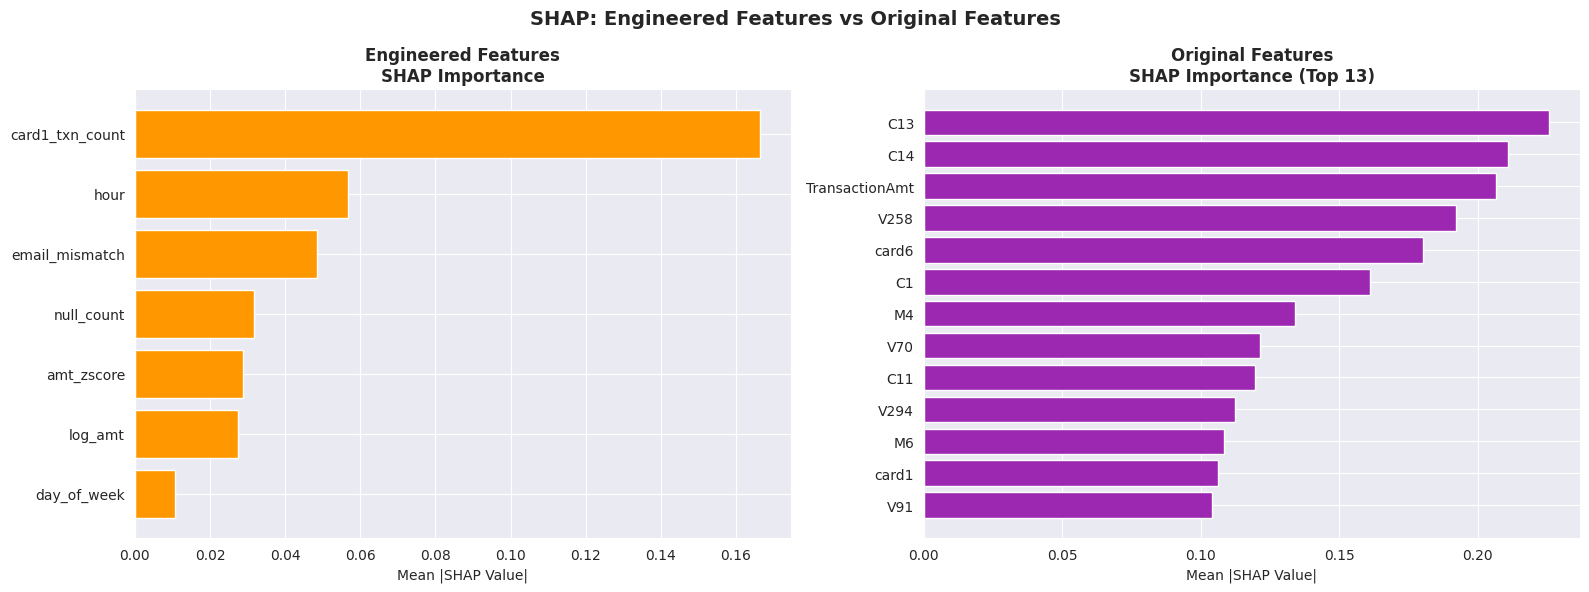

  Saved -> figures/33_shap_engineered_vs_original.png


In [10]:
# ── Define our 7 engineered features ─────────────────────────────────────────
engineered_features = [
    'null_count',       # missingness signal
    'email_mismatch',   # P vs R email domain
    'card1_txn_count',  # velocity per card
    'amt_zscore',       # amount deviation
    'log_amt',          # log-transformed amount
    'hour',             # time of day
    'day_of_week'       # day of week
]

# ── Split importance by feature origin ───────────────────────────────────────
eng_imp  = feature_importance[
    feature_importance.index.isin(engineered_features)
].sort_values(ascending=False)

orig_imp = feature_importance[
    ~feature_importance.index.isin(engineered_features)
].sort_values(ascending=False).head(13)

# ── Side-by-side comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Engineered features
axes[0].barh(eng_imp.index[::-1], eng_imp.values[::-1], color='#FF9800', edgecolor='white')
axes[0].set_title('Engineered Features\nSHAP Importance', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Mean |SHAP Value|')

# Original features (top 13)
axes[1].barh(orig_imp.index[::-1], orig_imp.values[::-1], color='#9C27B0', edgecolor='white')
axes[1].set_title('Original Features\nSHAP Importance (Top 13)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Mean |SHAP Value|')

plt.suptitle('SHAP: Engineered Features vs Original Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('33_shap_engineered_vs_original')

## 11. Final Ablation Study Chart
Ablation study confirming each component's independent contribution to the fusion model.

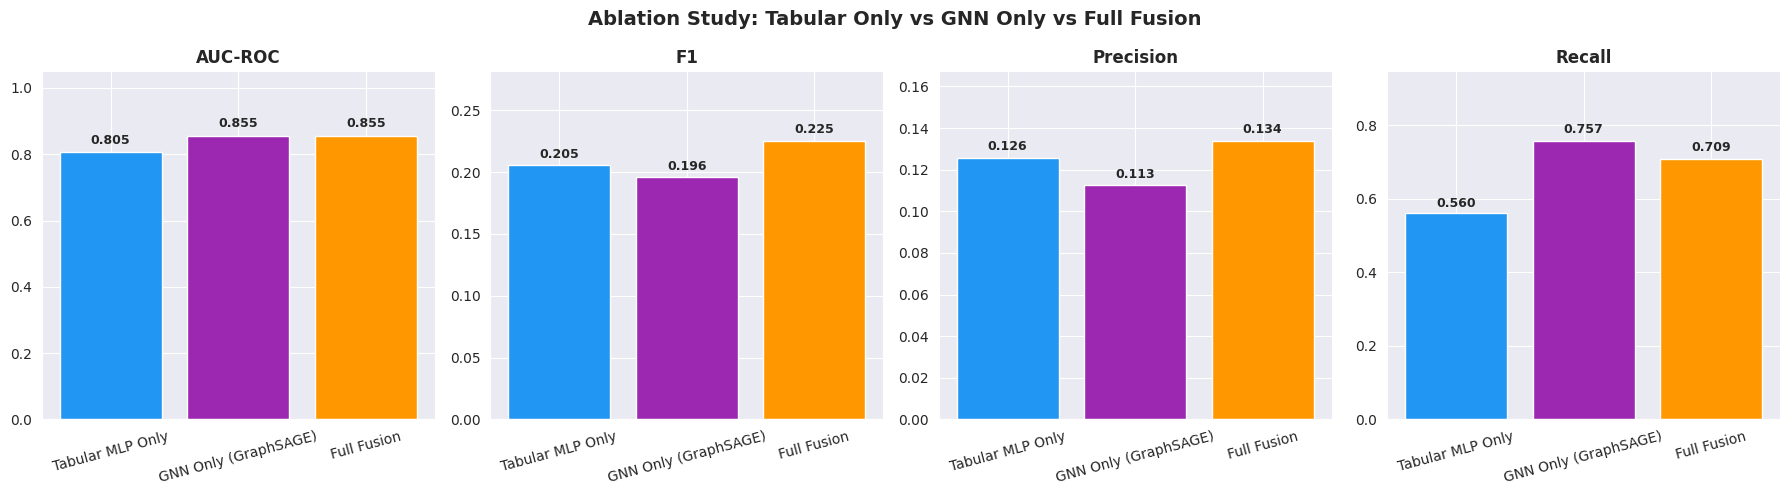

  Saved -> figures/34_ablation_final.png


In [11]:
# ── Plot ablation comparison ──────────────────────────────────────────────────
colors_abl = ['#2196F3','#9C27B0','#FF9800']  # tabular=blue, GNN=purple, fusion=orange
fig, axes  = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, ['AUC-ROC','F1','Precision','Recall']):
    vals = ablation_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors_abl, edgecolor='white')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, min(vals.max()*1.25, 1.05))
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Ablation Study: Tabular Only vs GNN Only vs Full Fusion',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('34_ablation_final')

## 12. Final FPR Comparison
False Positive Rate directly answers the research question: which model minimises false positives in e-commerce fraud detection?

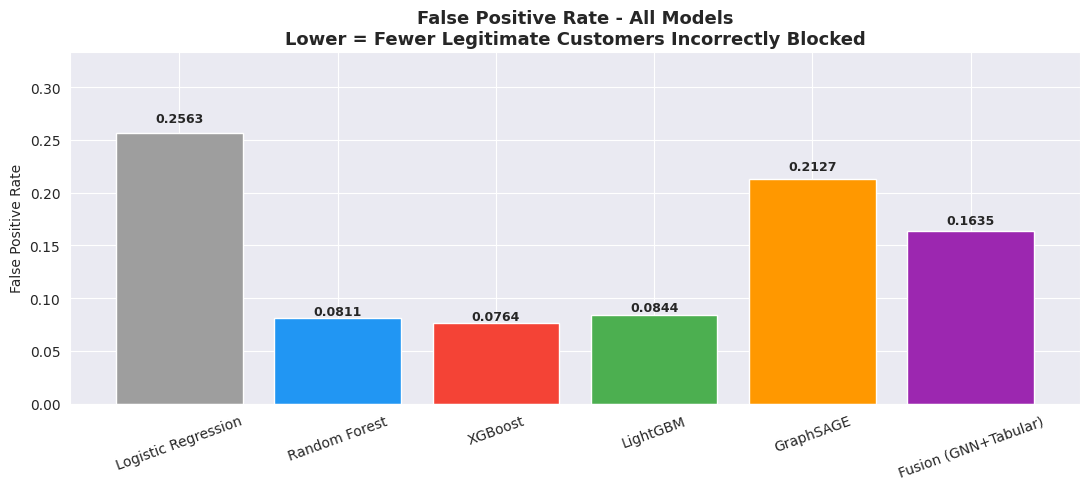

  Saved -> figures/35_fpr_final.png


In [12]:
# ── FPR comparison across all 6 models ───────────────────────────────────────
fpr_vals   = master_df['FPR'].dropna()
fpr_colors = ['#9E9E9E','#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0']

plt.figure(figsize=(11, 5))
bars = plt.bar(
    fpr_vals.index, fpr_vals.values,
    color=fpr_colors[:len(fpr_vals)], edgecolor='white'
)
# Add value labels
for bar, val in zip(bars, fpr_vals.values):
    plt.text(
        bar.get_x()+bar.get_width()/2, bar.get_height()*1.04,
        f'{val:.4f}', ha='center', fontweight='bold', fontsize=9
    )
plt.title(
    'False Positive Rate - All Models\n'
    'Lower = Fewer Legitimate Customers Incorrectly Blocked',
    fontsize=13, fontweight='bold'
)
plt.ylabel('False Positive Rate')
plt.xticks(rotation=20)
plt.ylim(0, max(fpr_vals.values)*1.3)
plt.tight_layout()
savefig('35_fpr_final')

## 13. Final Project Summary
Print the complete results summary for thesis writing.

In [13]:
# ── Print complete summary ────────────────────────────────────────────────────
print('FINAL PROJECT RESULTS SUMMARY')
print('='*70)
print()
print('Research Question:')
print('To what extent can GNNs + Multimodal Fusion improve fraud detection')
print('and reduce false positives in e-commerce environments?')
print()
print('Model Results:')
print(master_df[['AUC-ROC','F1','FPR']].to_string())
print()
print(f'Best model (AUC): {master_df["AUC-ROC"].idxmax()} '
      f'({master_df["AUC-ROC"].max():.4f})')
print(f'Best model (FPR): {master_df["FPR"].idxmin()} '
      f'({master_df["FPR"].min():.4f})')
print()
print('SHAP Top 5 Most Important Features:')
print(feature_importance.head(5).to_string())
print()
print('='*70)
print('ALL 5 NOTEBOOKS COMPLETE!')
print(f'Check /figures/ folder for all thesis-ready plots.')
print('Next step -> Write your thesis!')

FINAL PROJECT RESULTS SUMMARY

Research Question:
To what extent can GNNs + Multimodal Fusion improve fraud detection
and reduce false positives in e-commerce environments?

Model Results:
                      AUC-ROC      F1     FPR
Model                                        
Logistic Regression    0.8306  0.1703  0.2563
Random Forest          0.8715  0.3207  0.0811
XGBoost                0.9127  0.3683  0.0764
LightGBM               0.9099  0.3506  0.0844
GraphSAGE              0.8551  0.1961  0.2127
Fusion (GNN+Tabular)   0.8551  0.2251  0.1635

Best model (AUC): XGBoost (0.9127)
Best model (FPR): XGBoost (0.0764)

SHAP Top 5 Most Important Features:
C13               0.225699
C14               0.210877
TransactionAmt    0.206613
V258              0.192047
card6             0.180217

ALL 5 NOTEBOOKS COMPLETE!
Check /figures/ folder for all thesis-ready plots.
Next step -> Write your thesis!


In [15]:
import pandas as pd
BASE = '/content/drive/MyDrive/FraudProject'
df = pd.read_csv(f'{BASE}/processed/results_master.csv', index_col='Model')
print(df[['AUC-ROC','F1','Precision','Recall','FPR']].to_string())

                      AUC-ROC      F1  Precision  Recall     FPR
Model                                                           
Logistic Regression    0.8306  0.1703     0.0959  0.7625  0.2563
Random Forest          0.8715  0.3207     0.2156  0.6257  0.0811
XGBoost                0.9127  0.3683     0.2486  0.7096  0.0764
LightGBM               0.9099  0.3506     0.2321  0.7160  0.0844
GraphSAGE              0.8551  0.1961     0.1126  0.7574  0.2127
Fusion (GNN+Tabular)   0.8551  0.2251     0.1338  0.7089  0.1635


---
## Notebook Summary

| Analysis | Description | Figure |
|---|---|---|
| Master Results | All 6 models compared | Table |
| ROC Curves | Baseline progression | 25 |
| Precision-Recall | Better for imbalance | 26 |
| SHAP Bar | Top 20 features | 27 |
| SHAP Beeswarm | Feature impact direction | 28 |
| SHAP Waterfall | Individual predictions | 29-31 |
| SHAP Dependence | Feature value vs impact | 32 |
| Engineered vs Original | Feature engineering value | 33 |
| Ablation | Component contributions | 34 |
| FPR Final | Research question answer | 35 |